In [1]:
import torch 
import torch.nn as nn
import torch.nn.functional as F
import numpy as np 
import itertools
import scipy 
import math
import matplotlib.pyplot as plt
torch.set_default_dtype(torch.float64)
pi = torch.tensor(np.pi,dtype=torch.float64)

from utils import PiecewiseGQ2D_weights_points, SquareMesh2D_points
from utils import s2_uniform_grid_init
from utils import output_convergence_order_l2
from utils import plot_err_convergence

In [2]:
class ShallowReLUkNetwork:
    def __init__(self, ws, bs, train_pts, k=1, m1=1, m2=1):
        self.n = ws.shape[0]
        self.W = ws 
        self.b = bs
        self.k = k
        self.m1 = m1 
        self.m2 = m2
        self.pts = train_pts 
    
    def feat_extract(self, x):
        return F.relu(x @ self.W.t() + self.b) ** self.k

    def target(self, x):
        z = torch.sin(self.m1 * pi*x[:,0:1])*torch.sin(self.m2 * pi*x[:,1:2])
        return z 

    def assemble(self):
        A = self.feat_extract(self.pts)
        b = self.target(self.pts)
        return A, b

    def solve(self):
        A, b = self.assemble()

        c = 100.0 
        for i in range(len(A)):
            max_a = abs(A[i,:]).max()
            max_b = A[i,:].max()
            if max_a != max_b: 
                ratio = -c/max_a
                A[i,:] = A[i,:]*ratio
                b[i] = b[i]*ratio
            else: 
                ratio = c/max_a
                A[i,:] = A[i,:]*ratio
                b[i] = b[i]*ratio
        alpha = scipy.linalg.lstsq(A.numpy(),b.numpy())[0]
        self.alpha = torch.tensor(alpha)
        
    def forward(self, x):
        return self.feat_extract(x) @ self.alpha
    
    def eval(self, x):
        y_ref = self.target(x)
        y_pred = self.forward(x)
        rel_errl2 = (y_pred - y_ref).norm() / y_ref.norm()
        return rel_errl2.item()

In [3]:
x_train = SquareMesh2D_points(0,1,100)
x_test = SquareMesh2D_points(0,1,150)
k = 1
m1 = 1
m2 = 1
neuron_num_arr= np.array([2**i for i in range(6,12)]) 
neuron_arr = []
rel_errl2_arr = []
for i, n in enumerate(neuron_num_arr):
    ws, bs = s2_uniform_grid_init(n, k=k)
    model = ShallowReLUkNetwork(
        ws, bs, x_train, k=k, m1=2, m2=m2)
    model.solve()
    rel_errl2 = model.eval(x_test)
    neuron_arr.append(model.n)
    rel_errl2_arr.append(rel_errl2)
    print('num neuron : {:} - rel l2 : {:.4e}'.format(model.n, rel_errl2))
title = "L2 fitting. ReLU$^{}$. $\sin(m_1\pi x_1) \sin(m_2\pi x_2)$, $m_1,m_2 = {}, {}$".format(k, m1, m2)

num neuron : 31 - rel l2 : 1.6593e-01
num neuron : 57 - rel l2 : 7.7414e-02
num neuron : 113 - rel l2 : 3.8313e-02
num neuron : 227 - rel l2 : 1.5227e-02
num neuron : 445 - rel l2 : 7.0019e-03
num neuron : 897 - rel l2 : 2.7177e-03


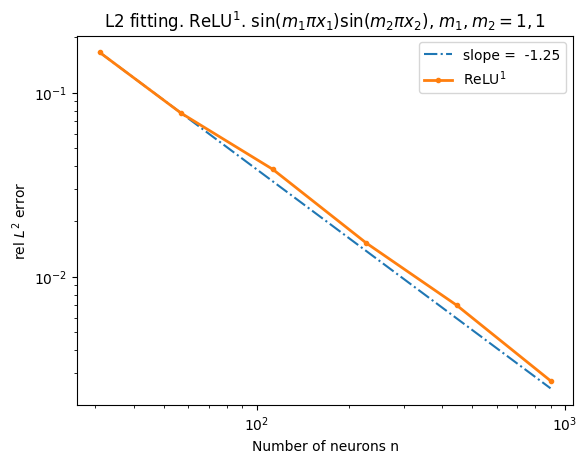

$n$ & 	 $\|u-u_n \|_{L^2}$ & 	 order  \\ \hline \hline 
31 		 & 1.659e-01 &		 *  \\ \hline  

57 		 &  7.741e-02 &  		 1.25  \\ \hline  

113 		 &  3.831e-02 &  		 1.03  \\ \hline  

227 		 &  1.523e-02 &  		 1.32  \\ \hline  

445 		 &  7.002e-03 &  		 1.15  \\ \hline  

897 		 &  2.718e-03 &  		 1.35  \\ \hline  



In [4]:
plot_err_convergence(1,2,torch.tensor(neuron_arr), rel_errl2_arr,title)
output_convergence_order_l2(torch.tensor(neuron_arr), rel_errl2_arr)